In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [2]:
file_path = r"C:\Users\Test\OneDrive\Desktop\GitHub Project 3\geophone-sensor-data.csv"

df = pd.read_csv(file_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      1800 non-null   object 
 1   mean           1800 non-null   float64
 2   top_3_mean     1800 non-null   float64
 3   min            1800 non-null   int64  
 4   max            1800 non-null   int64  
 5   std_dev        1800 non-null   float64
 6   median         1800 non-null   float64
 7   q1             1800 non-null   float64
 8   q3             1800 non-null   float64
 9   skewness       1800 non-null   float64
 10  dominant_freq  1800 non-null   float64
 11  energy         1800 non-null   float64
 12  activity       1800 non-null   object 
 13  name           1800 non-null   object 
dtypes: float64(9), int64(2), object(3)
memory usage: 197.0+ KB


In [3]:
df.head()

,timestamp,mean,top_3_mean,min,max,std_dev,median,q1,q3,skewness,dominant_freq,energy,activity,name
0,01:51:43,2046.726000,2057.666667,2035,2060,3.452186,2047.0,2043.0,2049.0,-0.152574,601.0,1.988682e+09,walking,Yusuf
1,01:51:46,2046.619333,2053.000000,2040,2053,3.580469,2047.0,2044.0,2050.0,-0.150615,300.0,1.988028e+09,walking,Yusuf
2,01:51:50,2046.598000,2056.000000,2030,2059,3.592826,2047.0,2044.0,2049.0,-0.370125,300.0,1.987897e+09,walking,Yusuf
3,01:51:53,2046.560000,2054.000000,2039,2055,3.414830,2047.0,2044.0,2049.0,-0.321296,300.0,1.987662e+09,walking,Yusuf
4,01:51:56,2046.656667,2055.000000,2034,2057,3.356802,2048.0,2044.0,2049.0,-0.379134,300.0,1.988255e+09,walking,Yusuf


In [4]:
df.isnull().sum()

timestamp        0
mean             0
top_3_mean       0
min              0
max              0
std_dev          0
median           0
q1               0
q3               0
skewness         0
dominant_freq    0
energy           0
activity         0
name             0
dtype: int64

In [9]:
non_numeric_columns= df.select_dtypes(include= ['object']).columns
print(non_numeric_columns)

df_numeric = df.drop(columns=['timestamp', 'activity', 'name'])

correlation_matrix= df_numeric.corr()
print(correlation_matrix)

Index(['timestamp', 'activity', 'name'], dtype='object')
                   mean  top_3_mean       min       max   std_dev    median  \
mean           1.000000    0.586015 -0.397227  0.560522  0.529001  0.935448   
top_3_mean     0.586015    1.000000 -0.941684  0.988481  0.951908  0.777938   
min           -0.397227   -0.941684  1.000000 -0.918581 -0.947530 -0.646051   
max            0.560522    0.988481 -0.918581  1.000000  0.921442  0.746482   
std_dev        0.529001    0.951908 -0.947530  0.921442  1.000000  0.762636   
median         0.935448    0.777938 -0.646051  0.746482  0.762636  1.000000   
q1             0.242465   -0.531275  0.674186 -0.520251 -0.636267 -0.068580   
q3             0.783915    0.920595 -0.841760  0.887822  0.937234  0.924091   
skewness      -0.214600   -0.417386  0.512459 -0.398811 -0.467078 -0.369547   
dominant_freq -0.403602   -0.416662  0.359493 -0.403257 -0.406273 -0.485775   
energy         0.999788    0.601249 -0.414667  0.575349  0.546203  0.94180

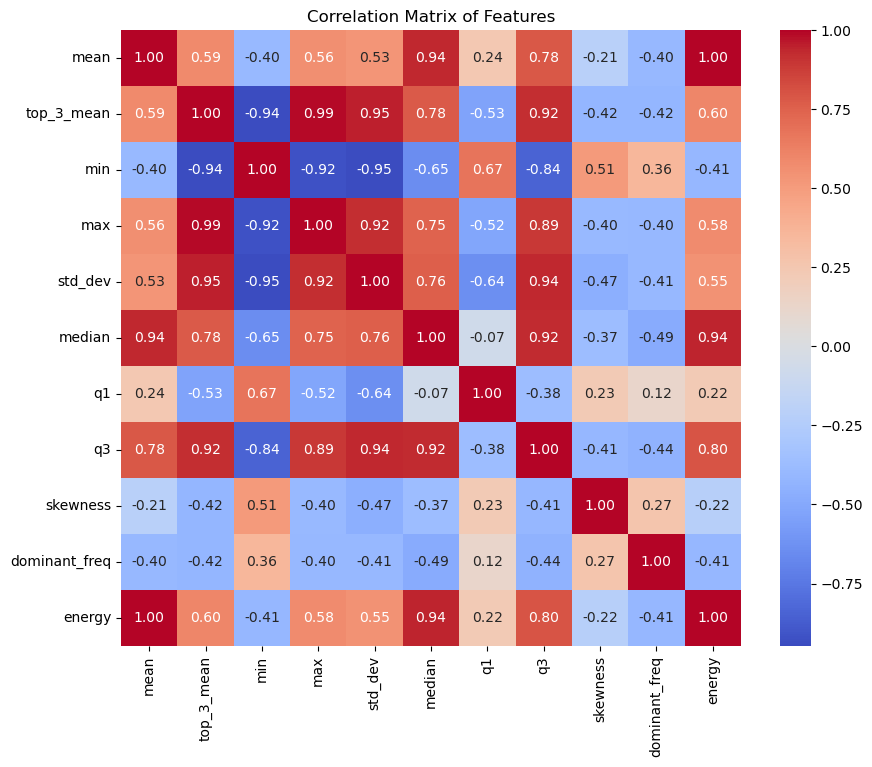

In [11]:
plt.figure(figsize= (10,8))
sns.heatmap(correlation_matrix, annot= True, cmap= "coolwarm", fmt= ".2f")
plt.title("Correlation Matrix of Features")
plt.show()

In [13]:
#Histogram for Key Features

# feature_to_plot= ['mean', 'std_dev', 'energy']
# df[feature_to_plot].hist(bins= 30, figsize=(10,6), edgecolor= "black")
# plt.suptitle("Distribution of Selected Features")
# plt.show()

In [15]:
#Acivity-wise Analysis

activity_stats = df.groupby('activity')[['mean', 'std_dev', 'energy']].mean()
print(activity_stats)

                 mean   std_dev        energy
activity                                     
running   2042.111688  9.062892  1.960706e+09
waiting   2041.250272  8.349315  1.955386e+09
walking   2043.377542  8.174275  1.968383e+09


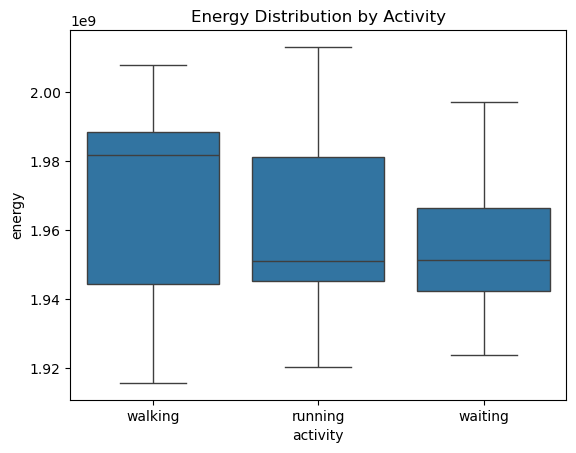

In [17]:
#FIGURE OUT THIS CODE

#Distribution of energy across activities

sns.boxplot(x='activity', y='energy', data=df)
plt.title("Energy Distribution by Activity")
plt.show()

C:\Users\Test\AppData\Local\Temp\ipykernel_27996\760905986.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df.resample('1T')[['energy']].mean().plot(title= 'Energy Trend Over time')


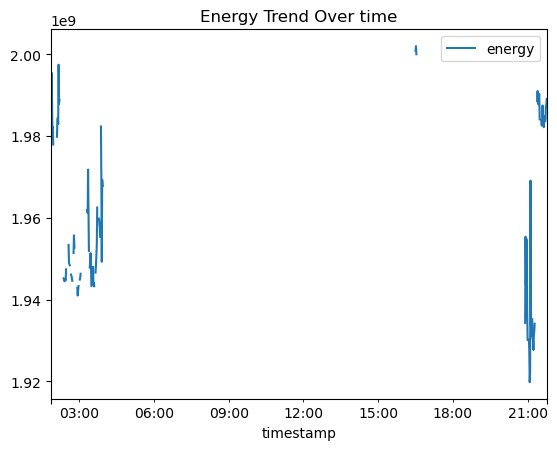

Index(['mean', 'top_3_mean', 'min', 'max', 'std_dev', 'median', 'q1', 'q3',
       'skewness', 'dominant_freq', 'energy', 'activity', 'name'],
      dtype='object')

In [19]:
#Temporal Trend Analysis
file_path = r"C:\Users\Test\OneDrive\Desktop\GitHub Project 3\geophone-sensor-data.csv"
df = pd.read_csv(file_path)

df['timestamp'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S')
df.set_index('timestamp', inplace= True)
df.resample('1T')[['energy']].mean().plot(title= 'Energy Trend Over time')
plt.show()

df.columns

In [21]:
#Person-Specific Patterns

person_stats= df.groupby('name')[['mean', 'energy']].mean()
print(person_stats)

               mean        energy
name                             
Alihan  2046.121207  1.986298e+09
Emir    2038.313644  1.937134e+09
Enes    2042.987681  1.965761e+09
Furkan  2040.187893  1.948610e+09
Yusuf   2043.622078  1.969655e+09


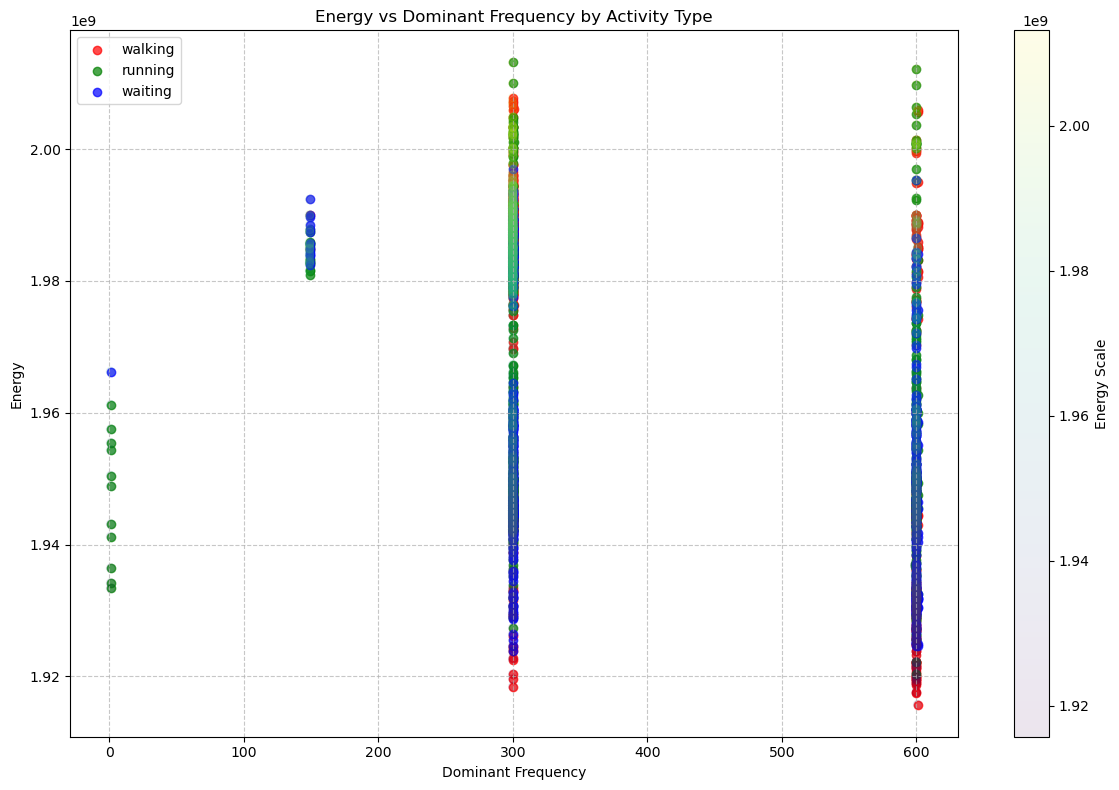

In [23]:
# Create the scatter plot
plt.figure(figsize=(12, 8))
activities = df['activity'].unique()
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Add more colors if needed

for i, activity in enumerate(activities):
    activity_data = df[df['activity'] == activity]
    plt.scatter(activity_data['dominant_freq'], activity_data['energy'], 
                c=colors[i % len(colors)], label=activity, alpha=0.7)

plt.xlabel('Dominant Frequency')
plt.ylabel('Energy')
plt.title('Energy vs Dominant Frequency by Activity Type')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

scatter = plt.scatter(df['dominant_freq'], df['energy'], c=df['energy'], cmap='viridis', alpha=0.1)
plt.colorbar(scatter, label='Energy Scale')

plt.tight_layout()
plt.show()

In [28]:
file_path = r"C:\Users\Test\OneDrive\Desktop\GitHub Project 3\geophone-sensor-data.csv"

df = pd.read_csv(file_path)

from statsmodels.tsa.seasonal import seasonal_decompose
print(df.columns)



Index(['timestamp', 'mean', 'top_3_mean', 'min', 'max', 'std_dev', 'median',
       'q1', 'q3', 'skewness', 'dominant_freq', 'energy', 'activity', 'name'],
      dtype='object')


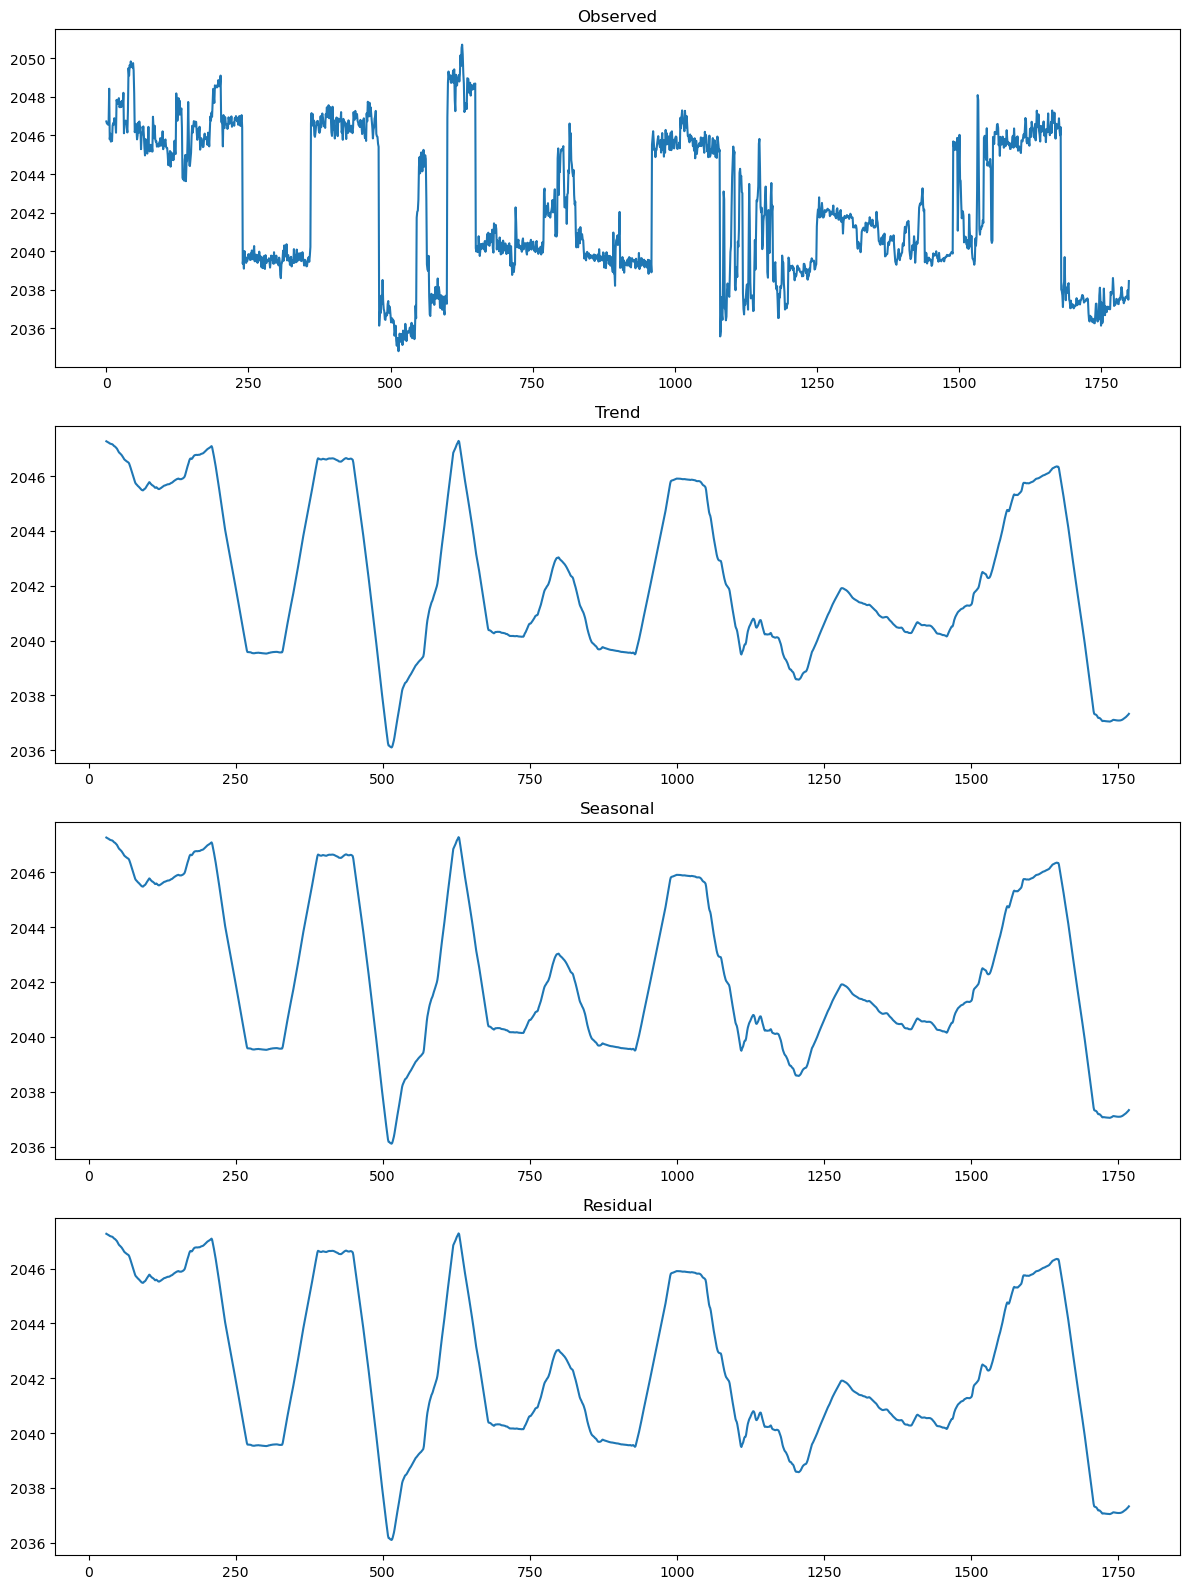

In [30]:
# df.set_index('timestamp', inplace= True)

result= seasonal_decompose(df['mean'], model= 'additive', period= 60)

#plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16))

result.observed.plot(ax= ax1)
ax1.set_title('Observed')

result.trend.plot(ax= ax2)
ax2.set_title('Trend')

result.trend.plot(ax= ax3)
ax3.set_title('Seasonal')

result.trend.plot(ax= ax4)
ax4.set_title('Residual')

plt.tight_layout()
plt.show()